# Complete Floor Plan Generation Pipeline (Research Grade)

## Agentic AI for Customer-Centric Architectural Design Assistance

This notebook provides an **end-to-end research-quality pipeline** for generating floor plans:

1. **Phase 1**: AI Chatbot gathers requirements through natural conversation
2. **Phase 2**: Requirements validated against architectural constraints and converted to House-GAN++ graph format (hub-and-spoke topology)
3. **Phase 3**: House-GAN++ generates floor plans with iterative refinement, mask post-processing, and best-of-N quality selection
4. **Phase 4**: Professional rendering with validation metrics

### Research Contributions
- **Architectural constraint enforcement**: Attached bathroom isolation, kitchen-hall adjacency, forbidden adjacency rules
- **Hub-and-spoke graph topology**: Matching RPLAN training data patterns (1:1 door-to-room ratio)
- **Quality scoring (0–100)**: Area balance, coverage, shape rectangularity, overlap penalty, adjacency fidelity
- **Mask post-processing**: Connected component cleanup, morphological hole-filling, overlap resolution

### Prerequisites
- Python 3.8+
- Google Gemini API Key (free at https://makersuite.google.com/app/apikey)
- House-GAN++ pretrained model (`houseganpp/checkpoints/pretrained.pth`)

## Section 1: Import Required Libraries

Import necessary libraries including PyTorch, NumPy, Matplotlib, and custom modules for House-GAN++ model integration.

In [40]:
# Install required packages (run once)
import sys
import warnings
warnings.filterwarnings('ignore')

# Check environment
try:
    import google.colab
    IN_COLAB = True
    print("Running on Google Colab")
except:
    IN_COLAB = False
    print(f"Running locally (Python {sys.version_info.major}.{sys.version_info.minor})")

# Install dependencies
print("\nInstalling dependencies...")
!pip install -q google-generativeai torch torchvision numpy pillow opencv-python webcolors matplotlib networkx

print("\nInstallation complete!")

Running locally (Python 3.13)

Installing dependencies...

Installation complete!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Import core libraries
import os
import sys
import json
import re
import datetime
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from typing import Dict, List, Optional

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Load .env file if it exists
env_path = os.path.join(PROJECT_ROOT, '.env')
if os.path.exists(env_path):
    with open(env_path, 'r') as f:
        for line in f:
            if '=' in line and not line.startswith('#'):
                key, value = line.strip().split('=', 1)
                os.environ.setdefault(key, value)
    print(f"Loaded environment from: {env_path}")

# Import research-grade modules
from houseganpp_integration.requirements_converter import RequirementsConverter
from houseganpp_integration.inference_v2 import HouseGANPPInferenceV2
from houseganpp_integration.template_selector import TemplateSelector
from houseganpp_integration.architectural_constraints import (
    validate_requirements, validate_graph, validate_masks,
    score_floor_plan, post_process_masks,
    ROOM_DISPLAY_NAMES, REAL_ROOM_TYPES, DOOR_TYPES,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Research modules loaded successfully.")

Loaded environment from: c:\AgenticAI\.env
Project root: c:\AgenticAI
PyTorch version: 2.9.1+cpu
CUDA available: False
Research modules loaded successfully.


## Section 2: Load Chatbot Agent for Input Collection

Initialize and configure the Gemini-based chatbot agent that collects user requirements through natural conversation.

In [42]:
# Configure Gemini API Key (from .env file or user prompt)
import os
import getpass

# Read from environment / .env (set in previous cell)
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY', '')

# Validate — prompt if missing
if not GEMINI_API_KEY or len(GEMINI_API_KEY) < 20:
    GEMINI_API_KEY = getpass.getpass("Enter your Gemini API Key: ")

print("API key configured!")
print(f"Key preview: {GEMINI_API_KEY[:8]}...{GEMINI_API_KEY[-4:]}")

API key configured!
Key preview: AIzaSyCy...KlMo


In [ ]:
# Initialize Gemini and define the Floor Plan Design Agent
import google.generativeai as genai
import time

genai.configure(api_key=GEMINI_API_KEY)

# ── Model fallback chain ──
# Free-tier daily quota is ~20 requests/model/day.  When one model's
# quota is exhausted the agent automatically falls through to the next.
_GEMINI_MODELS = [
    'gemini-2.5-flash',          # best quality, try first
    'gemini-2.5-flash-lite',     # lighter, separate daily quota
    'gemini-2.0-flash',          # older, separate daily quota
    'gemini-2.0-flash-lite',     # last resort
]

# ── System instruction — comprehensive architectural placement rules ──
_SYSTEM_INSTRUCTION = """\
You are a professional architectural consultant helping design single-floor residential floor plans.
Your goal is to extract EXACT requirements for a House-GAN++ floor plan generator.

SUPPORTED ROOM TYPES (only these can be generated):
- Living Room (always included, central hub of the home)
- Kitchen (always included, adjacent to living room)
- Bedrooms (1-4): Master bedroom always included
- Bathrooms (1-3): If ≥2, first is attached to master bedroom
- Dining Room (optional, can be combined with living room for open plan)
- Study Room (optional): connected to living room
- Storage / Pooja Room (optional): near kitchen or living/dining area

NOTE: This is a single-floor layout generator. Balconies are NOT supported.

ARCHITECTURAL PLACEMENT RULES YOU MUST ENFORCE:
1. Main entrance opens into the living room — NEVER into a bedroom or kitchen.
2. Living room is at the front/entry side and connects to dining and circulation.
3. Bedrooms do NOT open directly to main entrance — they connect through the living room.
4. Master bedroom is placed in the most private corner of the house.
5. Attached bathroom has a SINGLE door from its parent bedroom — no other access.
6. Common bathroom opens into a passage/corridor (near living area) — NOT inside kitchen or dining.
7. Kitchen is adjacent to dining area but AWAY from bedroom entrances and NOT directly facing the main entrance.
8. Kitchen must NEVER open directly into a toilet/bathroom.
9. Dining area is located between living room and kitchen (or combined with living).
10. No bedroom should be used as a passage to access another bedroom.
11. Toilet should NEVER open directly into dining area or kitchen.
12. Guest bedroom (if any) should be near living area with access to common bathroom.
13. Children's bedroom (if any) should be near master bedroom.
14. Pooja/store room should NOT be inside bathroom or bedroom — it can attach to living, dining, or kitchen.
15. Toilets and bedrooms should have only ONE door to enter.

INFORMATION TO COLLECT (in this order):
1. Number of bedrooms (1-4) and how many BHK they want
2. Number of bathrooms (1-3) — clarify attached (from master bedroom) vs common
3. Living/dining combined or separate dining room
4. Additional rooms: study room, storage/pooja room
5. Any special preferences (e.g. children's room near master, guest room near entrance)

If the user says "keep defaults" or similar, use these defaults:
- 2 bedrooms, 2 bathrooms (1 attached + 1 common), combined living-dining, no study, no storage

Keep the conversation natural and brief (3-5 exchanges max).
Ask about bedrooms first, then bathrooms, then extras.
NEVER suggest more than 4 bedrooms or 3 bathrooms.
Once you have all info, confirm the configuration and tell them to type 'done'."""


# ── Rate-limit safe API caller with model fallback ──
_last_api_call_time = 0.0
_MIN_CALL_INTERVAL = 4.0           # seconds between calls

def _call_with_retry(api_fn, *args, max_retries=3, **kwargs):
    """Call a Gemini API function with exponential backoff on rate-limit errors."""
    global _last_api_call_time

    for attempt in range(max_retries + 1):
        now = time.time()
        elapsed = now - _last_api_call_time
        if elapsed < _MIN_CALL_INTERVAL:
            time.sleep(_MIN_CALL_INTERVAL - elapsed)

        try:
            result = api_fn(*args, **kwargs)
            _last_api_call_time = time.time()
            return result
        except Exception as e:
            err_str = str(e).lower()
            is_rate_limit = any(k in err_str for k in (
                'resourceexhausted', '429', 'quota', 'rate',
            ))
            if is_rate_limit and attempt < max_retries:
                wait = min(10 * (2 ** attempt), 60)
                print(f"  [Rate limit] Waiting {wait}s ... (retry {attempt + 1}/{max_retries})")
                time.sleep(wait)
            else:
                raise


def _pick_working_model() -> str:
    """Probe the model fallback chain and return the first model with remaining quota."""
    for model_name in _GEMINI_MODELS:
        try:
            m = genai.GenerativeModel(model_name)
            m.generate_content("hi")
            time.sleep(2)
            return model_name
        except Exception as e:
            err = str(e).lower()
            if 'quota' in err or '429' in err:
                print(f"  {model_name}: daily quota exhausted, trying next...")
            elif 'not found' in err or '404' in err:
                continue
            else:
                print(f"  {model_name}: {str(e)[:60]}, trying next...")
    return _GEMINI_MODELS[0]


class FloorPlanDesignAgent:
    """AI Agent for gathering floor plan requirements through conversation.

    Enforces comprehensive architectural placement rules:
    - 1-4 bedrooms, 1-3 bathrooms
    - Attached bath: single door from master bedroom only
    - Kitchen adjacent to living room, away from bedrooms, not facing entrance
    - Common bath opens to corridor/living area, not kitchen/dining
    - Main entrance opens into living room, never into bedroom/kitchen
    - No bedroom-to-bedroom pass-through access
    - Toilet never opens into dining or kitchen
    - Single-floor layout (no balcony)
    """

    SUPPORTED_ROOMS = {
        'living_room': 1, 'kitchen': 2, 'bedroom': 3, 'bathroom': 4,
        'entrance': 6, 'dining_room': 7, 'study': 8, 'storage': 10
    }

    def __init__(self, api_key: str):
        genai.configure(api_key=api_key)

        # Auto-select a model with remaining daily quota
        print("  Probing available models...")
        selected = _pick_working_model()
        print(f"  Selected model: {selected}")

        self.model_name = selected
        self.model = genai.GenerativeModel(
            selected,
            system_instruction=_SYSTEM_INSTRUCTION,
        )
        self.chat = None
        self.conversation_history = []
        self.extracted_requirements = {}

    def _reinit_model_if_needed(self):
        """If the current model's quota runs out mid-session, switch to the next."""
        idx = _GEMINI_MODELS.index(self.model_name) if self.model_name in _GEMINI_MODELS else 0
        for name in _GEMINI_MODELS[idx + 1:]:
            try:
                m = genai.GenerativeModel(name, system_instruction=_SYSTEM_INSTRUCTION)
                m.generate_content("hi")
                time.sleep(2)
                print(f"  Switched to model: {name}")
                self.model_name = name
                self.model = m
                self.chat = self.model.start_chat(history=[])
                for msg in self.conversation_history:
                    role = "user" if msg["role"] == "user" else "model"
                    self.chat.history.append({"role": role, "parts": [msg["content"]]})
                return True
            except Exception:
                continue
        return False

    def start_conversation(self) -> str:
        """Start a new conversation session with a lightweight greeting."""
        self.chat = self.model.start_chat(history=[])
        try:
            response = _call_with_retry(
                self.chat.send_message,
                "Greet the customer and ask them to describe their ideal apartment "
                "(start with how many bedrooms they need). Mention they can say "
                "'keep defaults' for a standard 2BHK layout.",
            )
        except Exception:
            if self._reinit_model_if_needed():
                response = _call_with_retry(
                    self.chat.send_message,
                    "Greet the customer and ask them to describe their ideal apartment "
                    "(start with how many bedrooms they need). Mention they can say "
                    "'keep defaults' for a standard 2BHK layout.",
                )
            else:
                raise
        self.conversation_history = [{"role": "agent", "content": response.text}]
        return response.text

    def send_message(self, user_input: str) -> str:
        """Send user message and get response."""
        self.conversation_history.append({"role": "user", "content": user_input})
        try:
            response = _call_with_retry(self.chat.send_message, user_input)
        except Exception:
            if self._reinit_model_if_needed():
                response = _call_with_retry(self.chat.send_message, user_input)
            else:
                raise
        self.conversation_history.append({"role": "agent", "content": response.text})
        return response.text

    def extract_requirements(self) -> Dict:
        """Extract structured requirements from conversation."""
        conversation_text = "\n".join(
            [f"{m['role']}: {m['content']}" for m in self.conversation_history]
        )

        extraction_prompt = f"""Extract floor plan requirements from this conversation.

RULES:
- num_bedrooms must be 1-4
- num_bathrooms must be 1-3 and ≤ num_bedrooms + 1
- If num_bathrooms ≥ 2, the first is ATTACHED to master bedroom (accessible only from master bedroom)
- combined_living_dining=true means open-plan (no separate dining room)
- Kitchen is always adjacent to living room, away from bedrooms
- has_balcony is ALWAYS false (single-floor layout, no balcony)

Conversation:
{conversation_text}

Return ONLY valid JSON (use defaults where info is missing):
{{
    "num_bedrooms": <1-4, default 2>,
    "num_bathrooms": <1-3, default 2>,
    "has_balcony": false,
    "has_study": <true/false, default false>,
    "has_storage": <true/false, default false>,
    "combined_living_dining": <true/false, default true>,
    "notes": "<special preferences>"
}}"""

        try:
            response = _call_with_retry(self.model.generate_content, extraction_prompt)
            json_text = re.sub(r'```json\s*', '', response.text.strip())
            json_text = re.sub(r'```\s*$', '', json_text)
            json_match = re.search(r'\{.*\}', json_text, re.DOTALL)
            if json_match:
                raw = json.loads(json_match.group())
                raw['has_balcony'] = False  # Force no balcony
                validated, warnings = validate_requirements(raw)
                for w in warnings:
                    print(f"  [Validation] {w}")
                self.extracted_requirements = validated
                return self.extracted_requirements
        except Exception as e:
            print(f"Extraction error: {e}")

        # Safe defaults
        self.extracted_requirements = {
            "num_bedrooms": 2, "num_bathrooms": 2, "has_balcony": False,
            "has_study": False, "has_storage": False, "combined_living_dining": True
        }
        return self.extracted_requirements

    def get_summary(self) -> str:
        """Generate human-readable summary."""
        req = self.extracted_requirements
        num_bath = req.get('num_bathrooms', 1)
        num_bed = req.get('num_bedrooms', 2)
        has_attached = num_bath >= 2 or num_bed == 1

        lines = [
            "=" * 55,
            "FLOOR PLAN REQUIREMENTS (Validated)",
            "=" * 55,
            f"Configuration:  {num_bed} BHK",
            f"Bedrooms:       {num_bed} (Master + {max(0, num_bed-1)} additional)",
            f"Bathrooms:      {num_bath}",
        ]
        if has_attached:
            lines.append(f"  - Attached Bath: Yes (single door from Master Bedroom)")
            lines.append(f"  - Common Bath:   {max(0, num_bath-1)}")
        else:
            lines.append(f"  - Common Bath:   {num_bath} (accessible from living area)")

        lines.extend([
            f"Living Room:    Yes (central hub, at entrance side)",
            f"Kitchen:        Yes (adj. to living, away from bedrooms)",
            f"Dining Room:    {'Combined with Living' if req.get('combined_living_dining', True) else 'Separate (between living & kitchen)'}",
            f"Study:          {'Yes' if req.get('has_study') else 'No'}",
            f"Storage/Pooja:  {'Yes (near kitchen)' if req.get('has_storage') else 'No'}",
            "",
            "Placement Rules Active:",
            "  - Entrance → Living Room (not bedroom/kitchen)",
            "  - Bedrooms in private zone (away from entrance)",
            "  - Kitchen away from bedrooms, not facing entrance",
            "  - Bathroom not opening into kitchen/dining",
            "  - No bedroom-to-bedroom pass-through",
            "  - All rooms rectangularized for clean layout",
            "=" * 55,
        ])
        return "\n".join(lines)

# Initialize agent (auto-selects a model with remaining daily quota)
agent = FloorPlanDesignAgent(GEMINI_API_KEY)
print("Floor Plan Design Agent initialized!")

  Probing available models...
  Selected model: gemini-2.5-flash
Floor Plan Design Agent initialized!


## Section 3: Gather Requirements via AI Chatbot

**The AI architect will interview you** to collect all floor plan details through natural conversation.
All values are collected from you — nothing is hardcoded.

- Answer the agent's questions about bedrooms, bathrooms, balcony, etc.
- Type **`done`** when you've finished describing your requirements.

In [ ]:
# ============================================================
#  Gather Requirements via AI Chatbot
#  Type 'done' when you've described everything you need.
#  If Gemini API is unavailable, falls back to manual input.
# ============================================================
print("=" * 55)
print("  FLOOR PLAN DESIGN CONSULTATION")
print("=" * 55)

def _manual_input():
    """Fallback: collect requirements without Gemini."""
    print("\n  [Manual mode — enter your requirements directly]\n")
    nb  = int(input("  Number of bedrooms (1-4) [2]: ").strip() or "2")
    nba = int(input("  Number of bathrooms (1-3) [2]: ").strip() or "2")
    ld  = input("  Combined living+dining? (yes/no) [yes]: ").strip().lower()
    st  = input("  Include study room? (yes/no) [no]: ").strip().lower()
    sr  = input("  Include storage/pooja? (yes/no) [no]: ").strip().lower()
    return {
        "num_bedrooms": max(1, min(4, nb)),
        "num_bathrooms": max(1, min(3, nba)),
        "has_balcony": False,
        "combined_living_dining": ld != "no",
        "has_study": st == "yes",
        "has_storage": sr == "yes",
    }

chatbot_ok = True
try:
    print("\nThe AI architect will now interview you.")
    print("Describe your ideal apartment — type 'done' when finished.\n")

    greeting = agent.start_conversation()
    print(f"Agent: {greeting}\n")
except Exception as e:
    err = str(e).lower()
    if 'quota' in err or '429' in err or 'resourceexhausted' in err:
        print("\n  ⚠ All Gemini models have exhausted their free-tier daily quota.")
        print("  Switching to manual input so you can continue without waiting.\n")
    else:
        print(f"\n  ⚠ Chatbot error: {e}\n  Switching to manual input.\n")
    chatbot_ok = False

if chatbot_ok:
    while True:
        user_input = input("You: ").strip()
        if not user_input:
            continue
        if user_input.lower() in ('done', 'finished', "that's all", 'thats all', 'exit'):
            break
        try:
            response = agent.send_message(user_input)
            print(f"\nAgent: {response}\n")
        except Exception as e:
            err = str(e).lower()
            if 'quota' in err or '429' in err or 'resourceexhausted' in err:
                print("\n  ⚠ Daily quota reached mid-conversation. Switching to manual input.\n")
                chatbot_ok = False
                break
            else:
                raise

if chatbot_ok:
    # Extract structured requirements from conversation
    print("\n" + "-" * 40)
    print("Extracting requirements from conversation ...")
    FLOOR_PLAN_REQUIREMENTS = agent.extract_requirements()
else:
    FLOOR_PLAN_REQUIREMENTS = _manual_input()

# Validate through architectural constraints
FLOOR_PLAN_REQUIREMENTS, val_warnings = validate_requirements(FLOOR_PLAN_REQUIREMENTS)
agent.extracted_requirements = FLOOR_PLAN_REQUIREMENTS

if val_warnings:
    print("\nValidation adjustments:")
    for w in val_warnings:
        print(f"  ! {w}")

# Show summary
print("\n" + agent.get_summary())

# Confirm
confirm = input("\nProceed with these requirements? (yes/no) [yes]: ").strip().lower()
if confirm == 'no':
    print("\n  Re-run this cell to start over.")
else:
    print("\n  Requirements confirmed! Ready for generation.")

  FLOOR PLAN DESIGN CONSULTATION

The AI architect will now interview you.
Describe your ideal apartment — type 'done' when finished.



Agent: Hello! I'm here to help you design your ideal apartment floor plan. Let's start with the basics:

How many bedrooms would you like for your apartment (1-4)? You can also say 'keep defaults' for a standard 2BHK layout.


Agent: Great, 2 bedrooms it is!

Now, how many bathrooms would you like (1-3)? Also, for your master bedroom, would you prefer an attached bathroom, or would you like all bathrooms to be common?

  [Rate limit] Waiting 10s ... (retry 1/3)
  [Rate limit] Waiting 20s ... (retry 2/3)
  [Rate limit] Waiting 40s ... (retry 3/3)
  Switched to model: gemini-2.5-flash-lite
  [Rate limit] Waiting 10s ... (retry 1/3)
  [Rate limit] Waiting 20s ... (retry 2/3)
  [Rate limit] Waiting 40s ... (retry 3/3)

  ⚠ Daily quota reached mid-conversation. Switching to manual input.


  [Manual mode — enter your requirements directly]


FLOOR PLAN REQUIREMENTS (Validated)
Configuration:  2 BHK
Bedrooms:       2 (Master + 1 additional)
Bathrooms:      2
  - Attached Bath: Yes (single do

## Section 4: Define Input Schema and Extract Requirements

Extract the structured requirements in House-GAN++ compatible format.

In [ ]:
# Display validated requirements in JSON format
print("Validated Requirements\n")
print(json.dumps(FLOOR_PLAN_REQUIREMENTS, indent=2))

# Additional architectural rules active
print("\nArchitectural Rules Enforced:")
print("  - Kitchen MUST be adjacent to Living Room")
print("  - Kitchen MUST be adjacent to Dining Room (when separate)")
print("  - Attached Bathroom: single door from Master Bedroom only")
print("  - FORBIDDEN: Kitchen-Bathroom, Bedroom-Kitchen,")
print("               Bathroom-Dining, Bedroom-Entrance adjacency")
print("  - Hub-and-spoke topology with 1:1 door-to-room ratio")
print("  - Area proportions follow NBC India 2016 guidelines")

Validated Requirements

{
  "num_bedrooms": 2,
  "num_bathrooms": 2,
  "has_balcony": true,
  "combined_living_dining": true,
  "has_study": false,
  "has_storage": false,
  "_total_real_rooms": 7
}

Architectural Rules Enforced:
  - Kitchen MUST be adjacent to Living Room
  - Kitchen MUST be adjacent to Dining Room (when separate)
  - Attached Bathroom: single door from Master Bedroom only
  - FORBIDDEN: Kitchen-Bathroom, Bathroom-Balcony,
               Bedroom-Kitchen, Bathroom-Dining adjacency
  - Hub-and-spoke topology with 1:1 door-to-room ratio
  - Area proportions follow NBC India 2016 guidelines


---

# Phase 2: House-GAN++ Floor Plan Generation

## Section 5: Load Model & Architectural Modules

Load the pretrained House-GAN++ generator and research-grade validation modules.

In [46]:
# Setup House-GAN++ model path
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, 'houseganpp', 'checkpoints', 'pretrained.pth')

if os.path.exists(CHECKPOINT_PATH):
    print(f"Model checkpoint found: {CHECKPOINT_PATH}")
else:
    print(f"Checkpoint not found at: {CHECKPOINT_PATH}")
    raise FileNotFoundError("Please ensure House-GAN++ pretrained model is available")

Model checkpoint found: c:\AgenticAI\houseganpp\checkpoints\pretrained.pth


In [47]:
# Load House-GAN++ inference engine (research-grade V2)
print("Loading House-GAN++ model ...")

try:
    from houseganpp_integration.inference_v2 import HouseGANPPInferenceV2
    from houseganpp_integration.requirements_converter import RequirementsConverter
    from houseganpp_integration.architectural_constraints import (
        validate_graph, validate_masks, score_floor_plan, post_process_masks, AREA_PROPORTIONS
    )
    print("  House-GAN++ V2 integration loaded")
except ImportError as e:
    print(f"Import error: {e}")
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'houseganpp_integration'))
    from inference_v2 import HouseGANPPInferenceV2
    from requirements_converter import RequirementsConverter
    from architectural_constraints import (
        validate_graph, validate_masks, score_floor_plan, post_process_masks, AREA_PROPORTIONS
    )

# Initialize inference engine
inference_engine = HouseGANPPInferenceV2(checkpoint_path=CHECKPOINT_PATH)
print(f"  Device: {inference_engine.device}")
print(f"\nResearch-grade features active:")
print(f"  - Hub-and-spoke topology (RPLAN training distribution)")
print(f"  - 1:1 door-to-room ratio")
print(f"  - Attached bath isolation (door from parent bedroom only)")
print(f"  - Mandatory / forbidden adjacency enforcement")
print(f"  - Best-of-N quality selection with 0-100 scoring")
print(f"  - Post-processing: morphological closing, overlap resolution")

Loading House-GAN++ model ...
  House-GAN++ V2 integration loaded


✅ Loaded House-GAN++ weights from c:\AgenticAI\houseganpp\checkpoints\pretrained.pth
  Device: cpu

Research-grade features active:
  - Hub-and-spoke topology (RPLAN training distribution)
  - 1:1 door-to-room ratio
  - Attached bath isolation (door from parent bedroom only)
  - Mandatory / forbidden adjacency enforcement
  - Best-of-N quality selection with 0-100 scoring
  - Post-processing: morphological closing, overlap resolution


## Section 6: Convert Requirements to Graph Representation

Convert the chatbot-collected requirements into a graph with room nodes and adjacency edges.

In [48]:
# Convert requirements to House-GAN++ graph format
print("Converting requirements to graph ...\n")

converter = RequirementsConverter()
nodes, edges, room_names = converter.convert(FLOOR_PLAN_REQUIREMENTS)

# Print concise graph summary from converter
summary = converter.get_graph_summary(nodes, edges, room_names)
print(summary)

# Run graph validation
graph_vr = validate_graph(nodes, edges, room_names)
graph_ok = graph_vr.is_valid
graph_issues = graph_vr.errors + graph_vr.warnings

print(f"\nGraph validation: {'PASS' if graph_ok else 'ISSUES DETECTED'}")
if graph_issues:
    for issue in graph_issues:
        print(f"  {'!' if not graph_ok else '-'} {issue}")
if graph_vr.scores:
    for k, v in graph_vr.scores.items():
        print(f"  {k}: {v:.2f}")

# Room type names
ROOM_TYPE_NAMES = {
    1: 'Living Room', 2: 'Kitchen', 3: 'Bedroom', 4: 'Bathroom',
    5: 'Balcony', 6: 'Entrance', 7: 'Dining Room', 8: 'Study',
    10: 'Storage', 15: 'Front Door', 17: 'Interior Door'
}

# Count rooms (excluding doors)
room_counts = {}
for node_type, name in zip(nodes, room_names):
    if node_type not in [15, 17]:
        room_type = ROOM_TYPE_NAMES.get(node_type, 'Unknown')
        room_counts[room_type] = room_counts.get(room_type, 0) + 1

print(f"\nRoom Configuration:")
for room_type, count in room_counts.items():
    print(f"  {room_type}: {count}")

num_real = sum(room_counts.values())
num_doors = len([n for n in nodes if n in [15, 17]])
print(f"\nReal rooms: {num_real} | Doors: {num_doors} | Total nodes: {len(nodes)} | Edges: {len(edges)}")

Converting requirements to graph ...

GRAPH SUMMARY
Total nodes:       14
  Real rooms:      7
  Interior doors:  6
  Front doors:     1
Door:room ratio:   6:7 (OK (N-1):N)
Edge triples:      91
  Adjacent (+1):   21
  Non-adj  (-1):   70
-------------------------------------------------------
Room List:
  [ 0] Master Bedroom         (type  3: Bedroom)
  [ 1] Bedroom 2              (type  3: Bedroom)
  [ 2] Attached Bath          (type  4: Bathroom)
  [ 3] Bathroom 2             (type  4: Bathroom)
  [ 4] Kitchen                (type  2: Kitchen)
  [ 5] Balcony                (type  5: Balcony)
  [ 6] Living Room            (type  1: Living Room)
  [ 7] Door 1                 (type 17: Interior Door)
  [ 8] Door 2                 (type 17: Interior Door)
  [ 9] Door 3                 (type 17: Interior Door)
  [10] Door 4                 (type 17: Interior Door)
  [11] Door 5                 (type 17: Interior Door)
  [12] Door 6                 (type 17: Interior Door)
  [13] Front Do

## Section 7: Generate Floor Plans (Best-of-N with Quality Scoring)

**Generation approach:**
- Hub-and-spoke graph with living room as central hub (matches RPLAN training distribution)
- Best-of-N candidate generation: multiple candidates scored on a 0–100 scale
- Scoring criteria: area balance (25%), coverage (20%), shape rectangularity (20%), overlap penalty (20%), adjacency fidelity (15%)
- Post-processing: morphological closing, connected-component cleanup, overlap resolution

PHASE 3: FLOOR PLAN GENERATION

Step 1: Input Graph Visualization
----------------------------------------


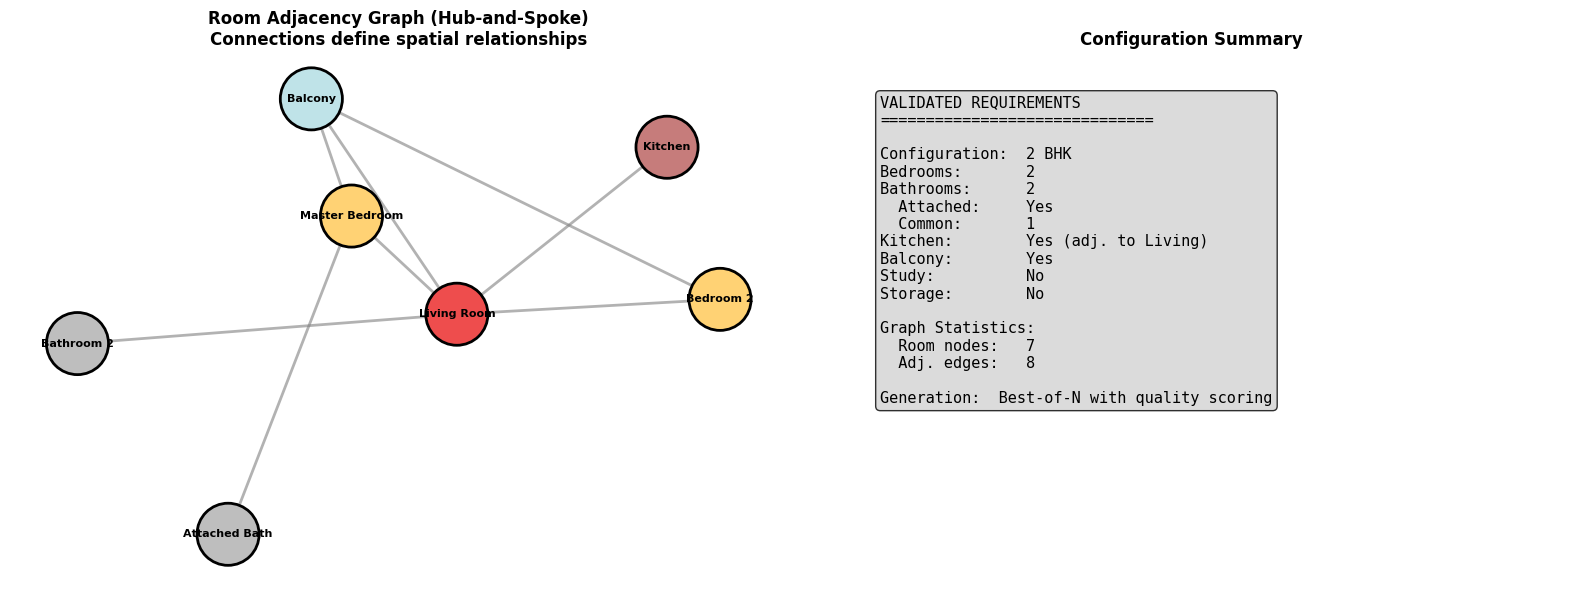


  Graph has 7 rooms with 8 adjacency edges

Step 2: House-GAN++ Best-of-N Generation
----------------------------------------
Generating 8 candidates (base seed 1450) ...
Each candidate is scored on area balance, coverage, shape, overlap, adjacency.


  Floor plan generated!
  Output size : (732, 512)
  Quality score: 85.6 / 100
  Rooms: 7
  Mask validation: PASS
    - Kitchen (idx 4): proportion 3.2% far below expected 7%–14%


In [49]:
# ============================================================
#  PHASE 3: FLOOR PLAN GENERATION  (best-of-N with scoring)
# ============================================================
print("=" * 60)
print("PHASE 3: FLOOR PLAN GENERATION")
print("=" * 60)

# ---- Step 1: Visualise input graph ----
print("\nStep 1: Input Graph Visualization")
print("-" * 40)

import networkx as nx

ROOM_COLORS = {
    1: '#EE4D4D',   # Living room
    2: '#C67C7B',   # Kitchen
    3: '#FFD274',   # Bedroom
    4: '#BEBEBE',   # Bathroom
    5: '#BFE3E8',   # Balcony
    6: '#7BA779',   # Entrance
    7: '#E87A90',   # Dining
    8: '#FF8C69',   # Study
    10: '#1F849B',  # Storage
    15: '#727171',  # Front door
    17: '#D3A2C7',  # Interior door
}

G = nx.Graph()
for i, (node_type, name) in enumerate(zip(nodes, room_names)):
    if node_type not in [15, 17]:
        G.add_node(i, label=name, color=ROOM_COLORS.get(node_type, '#FFFFFF'),
                   room_type=node_type)

for edge in edges:
    src, rel, dst = int(edge[0]), int(edge[1]), int(edge[2])
    if rel == 1 and nodes[src] not in [15, 17] and nodes[dst] not in [15, 17]:
        G.add_edge(src, dst)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

node_colors = [G.nodes[n]['color'] for n in G.nodes()]
labels = {n: G.nodes[n]['label'] for n in G.nodes()}
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color='gray', width=2, alpha=0.6)
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=node_colors,
                       node_size=2000, edgecolors='black', linewidths=2)
nx.draw_networkx_labels(G, pos, labels, ax=axes[0], font_size=8, font_weight='bold')
axes[0].set_title('Room Adjacency Graph (Hub-and-Spoke)\n'
                  'Connections define spatial relationships',
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Right panel: configuration summary
axes[1].axis('off')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
nb = FLOOR_PLAN_REQUIREMENTS.get('num_bedrooms', 2)
nba = FLOOR_PLAN_REQUIREMENTS.get('num_bathrooms', 1)
summary_text = (
    f"VALIDATED REQUIREMENTS\n{'=' * 30}\n\n"
    f"Configuration:  {nb} BHK\n"
    f"Bedrooms:       {nb}\n"
    f"Bathrooms:      {nba}\n"
    f"  Attached:     {'Yes' if nba >= 2 or nb == 1 else 'No'}\n"
    f"  Common:       {max(0, nba - 1)}\n"
    f"Kitchen:        Yes (adj. to Living)\n"
    f"Balcony:        {'Yes' if FLOOR_PLAN_REQUIREMENTS.get('has_balcony') else 'No'}\n"
    f"Study:          {'Yes' if FLOOR_PLAN_REQUIREMENTS.get('has_study') else 'No'}\n"
    f"Storage:        {'Yes' if FLOOR_PLAN_REQUIREMENTS.get('has_storage') else 'No'}\n\n"
    f"Graph Statistics:\n"
    f"  Room nodes:   {G.number_of_nodes()}\n"
    f"  Adj. edges:   {G.number_of_edges()}\n\n"
    f"Generation:  Best-of-N with quality scoring"
)
axes[1].text(0.1, 0.92, summary_text, transform=axes[1].transAxes,
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
axes[1].set_title('Configuration Summary', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n  Graph has {G.number_of_nodes()} rooms with {G.number_of_edges()} adjacency edges")

# ---- Step 2: Best-of-N generation with quality scoring ----
print("\nStep 2: House-GAN++ Best-of-N Generation")
print("-" * 40)

import random
N_CANDIDATES = 8
SEED = random.randint(1, 10000)
print(f"Generating {N_CANDIDATES} candidates (base seed {SEED}) ...")
print("Each candidate is scored on area balance, coverage, shape, overlap, adjacency.\n")

result = inference_engine.generate_best_of_n(
    nodes, edges, room_names,
    n_candidates=N_CANDIDATES,
    num_iterations=5,
    base_seed=SEED,
)

score = result.get('score', 0)
print(f"\n  Floor plan generated!")
print(f"  Output size : {result['image'].size}")
print(f"  Quality score: {score:.1f} / 100")
print(f"  Rooms: {len([n for n in result['nodes'] if n not in [15, 17]])}")

# Run mask validation
mask_vr = validate_masks(result['masks'], result['nodes'])
print(f"  Mask validation: {'PASS' if mask_vr.is_valid else 'ISSUES'}")
if mask_vr.warnings:
    for mi in mask_vr.warnings[:5]:
        print(f"    - {mi}")

# Save for later reference
mask_issues = mask_vr.warnings + mask_vr.errors
masks_ok = mask_vr.is_valid


Step 3: Floor Plan Visualization
----------------------------------------


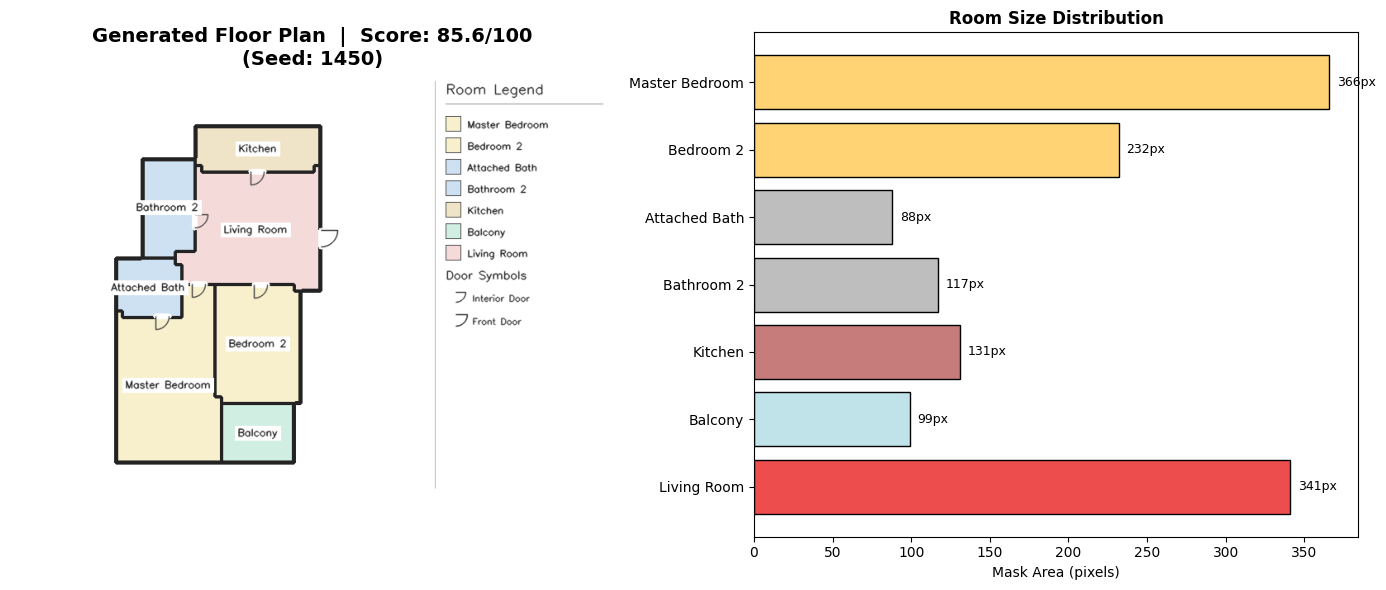


  Rooms rendered: 7
  Largest:  Master Bedroom (366 px)
  Smallest: Attached Bath (88 px)


In [50]:
# Display the generated floor plan with quality metrics
print("\nStep 3: Floor Plan Visualization")
print("-" * 40)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Main floor plan
axes[0].imshow(result['image'])
axes[0].set_title(f'Generated Floor Plan  |  Score: {score:.1f}/100\n(Seed: {SEED})',
                  fontsize=14, fontweight='bold')
axes[0].axis('off')

# 2. Room area analysis
masks = result['masks']
room_info = []
for i, (m, nd, name) in enumerate(zip(masks, result['nodes'], result['room_names'])):
    if nd in [15, 17]:
        continue
    area = np.sum(m > 0)
    pct = area / (m.shape[0] * m.shape[1]) * 100
    room_info.append((name, nd, area, pct))

room_names_plot = [r[0] for r in room_info]
room_areas = [r[2] for r in room_info]
room_colors_plot = [ROOM_COLORS.get(r[1], '#808080') for r in room_info]

bars = axes[1].barh(room_names_plot, room_areas, color=room_colors_plot, edgecolor='black')
axes[1].set_xlabel('Mask Area (pixels)', fontsize=10)
axes[1].set_title('Room Size Distribution', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

for bar, area in zip(bars, room_areas):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{area}px', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Quality breakdown
print(f"\n  Rooms rendered: {len(room_info)}")
print(f"  Largest:  {max(room_info, key=lambda x: x[2])[0]} ({max(room_info, key=lambda x: x[2])[2]} px)")
print(f"  Smallest: {min(room_info, key=lambda x: x[2])[0]} ({min(room_info, key=lambda x: x[2])[2]} px)")


Step 4: Generating Layout Variations (best-of-N each)
----------------------------------------
  Variation 1/6  seed=5758  score=81.3
  Variation 2/6  seed=3492  score=84.1
  Variation 3/6  seed=3334  score=83.2
  Variation 4/6  seed=6382  score=85.7
  Variation 5/6  seed=608  score=81.1
  Variation 6/6  seed=353  score=84.3


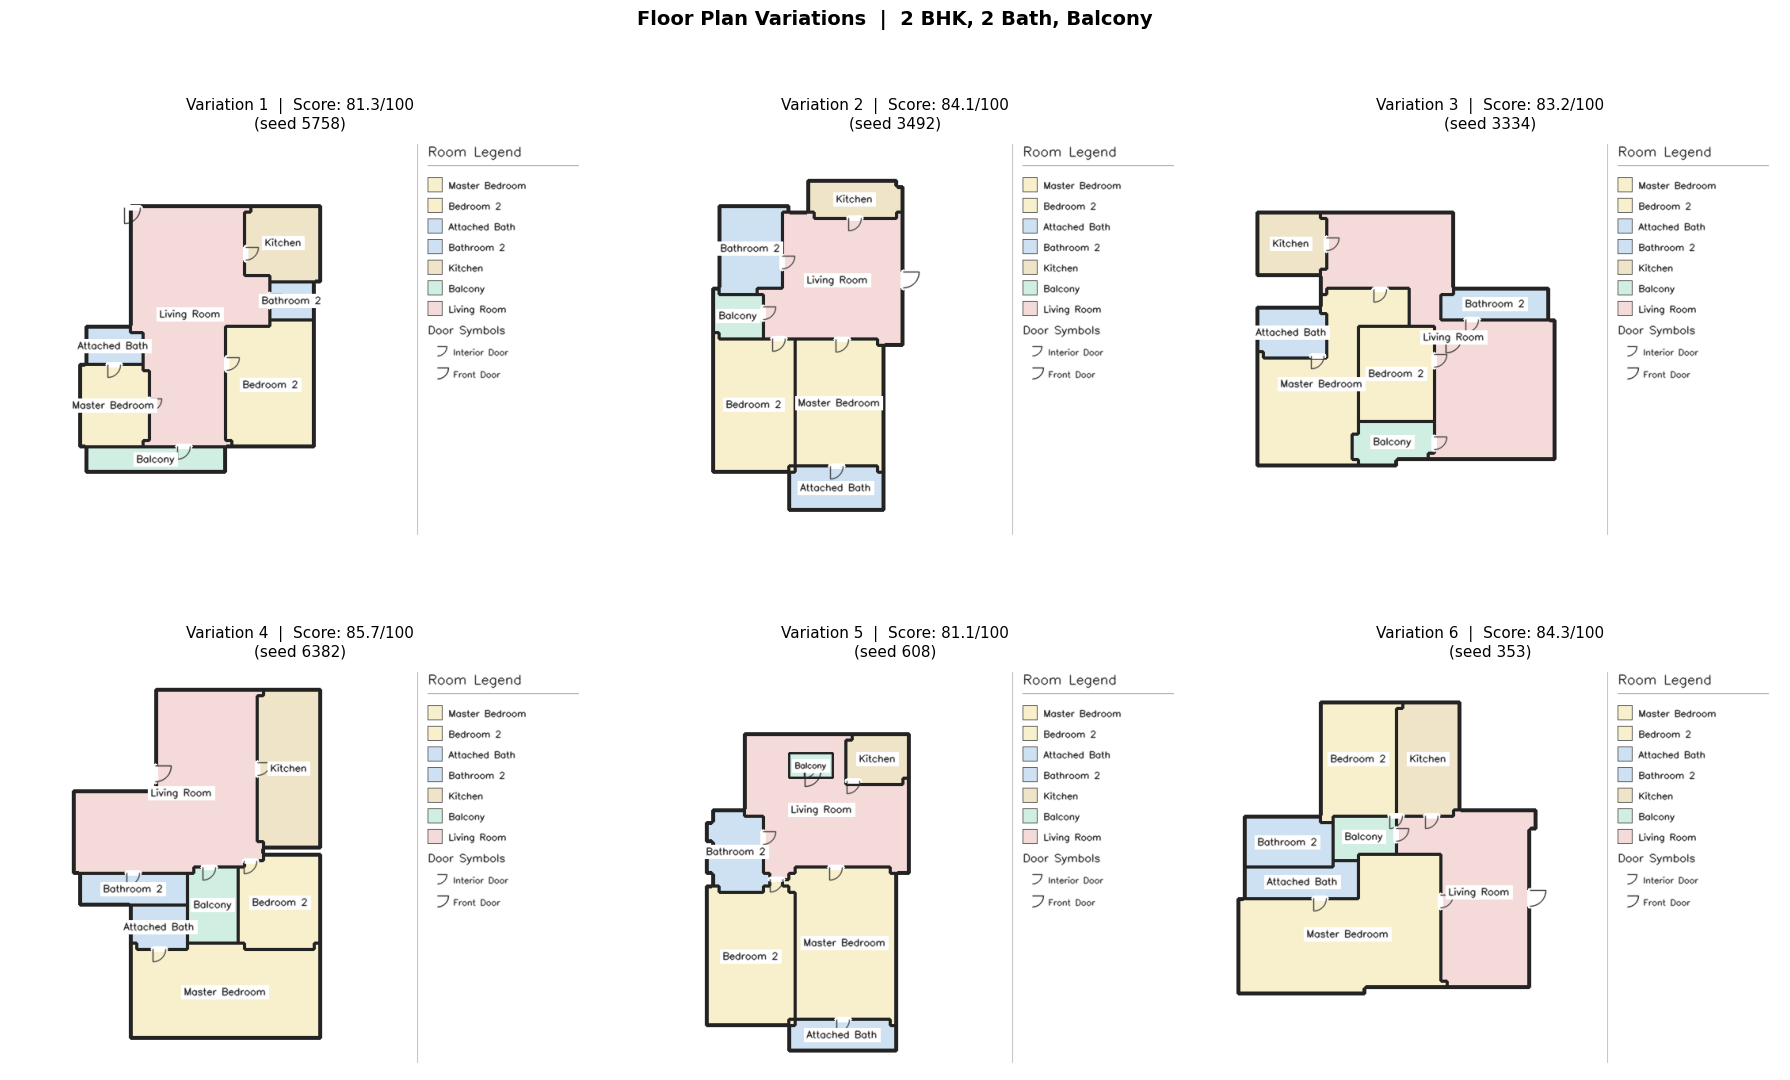


  Generated 6 variations
  Score range: 81.1 - 85.7
  Mean score:  83.3


In [51]:
# Generate multiple variations with quality scoring
print("\nStep 4: Generating Layout Variations (best-of-N each)")
print("-" * 40)

NUM_VARIATIONS = 6
N_CANDIDATES_PER = 4            # candidates per variation
variation_seeds = [random.randint(1, 10000) for _ in range(NUM_VARIATIONS)]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
variations = []

for idx, var_seed in enumerate(variation_seeds):
    variation = inference_engine.generate_best_of_n(
        nodes, edges, room_names,
        n_candidates=N_CANDIDATES_PER,
        num_iterations=5,
        base_seed=var_seed,
    )
    var_score = variation.get('score', 0)
    variations.append({'seed': var_seed, 'result': variation, 'score': var_score})

    axes[idx].imshow(variation['image'])
    axes[idx].set_title(f'Variation {idx+1}  |  Score: {var_score:.1f}/100\n'
                        f'(seed {var_seed})', fontsize=11)
    axes[idx].axis('off')
    print(f"  Variation {idx+1}/{NUM_VARIATIONS}  seed={var_seed}  score={var_score:.1f}")

nb = FLOOR_PLAN_REQUIREMENTS.get('num_bedrooms', 2)
nba = FLOOR_PLAN_REQUIREMENTS.get('num_bathrooms', 1)
plt.suptitle(
    f'Floor Plan Variations  |  {nb} BHK, {nba} Bath'
    f'{", Balcony" if FLOOR_PLAN_REQUIREMENTS.get("has_balcony") else ""}'
    f'{", Study" if FLOOR_PLAN_REQUIREMENTS.get("has_study") else ""}',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

scores = [v['score'] for v in variations]
print(f"\n  Generated {NUM_VARIATIONS} variations")
print(f"  Score range: {min(scores):.1f} - {max(scores):.1f}")
print(f"  Mean score:  {np.mean(scores):.1f}")


Step 5: Auto-Select & Save Best Layout
----------------------------------------
  Selected seed 6382 with score 85.7/100

  Files saved:
    image: floorplan_2BR_2BA_20260226_113017.png
    masks: floorplan_2BR_2BA_20260226_113017_masks.npy
    metadata: floorplan_2BR_2BA_20260226_113017_meta.json
    session: floorplan_2BR_2BA_20260226_113017_session.json


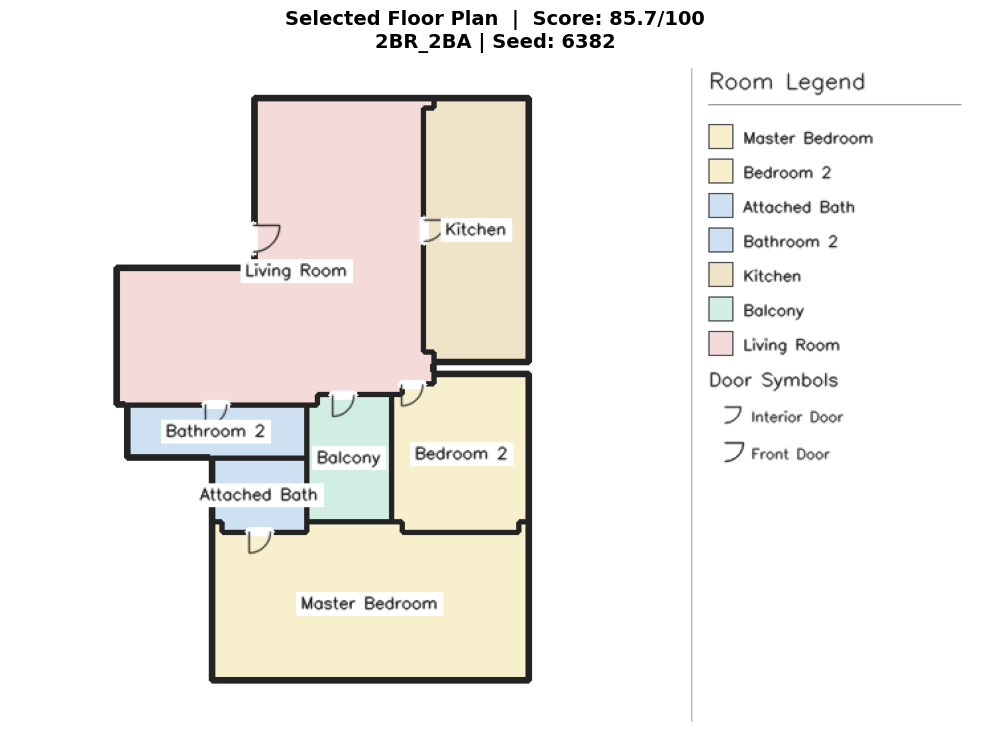

In [52]:
# Auto-select the best variation by quality score and save
print("\nStep 5: Auto-Select & Save Best Layout")
print("-" * 40)

# Include the initial best-of-N result as a candidate too
all_candidates = [{'seed': SEED, 'result': result, 'score': result.get('score', 0)}] + variations
best_variation = max(all_candidates, key=lambda v: v['score'])
best_seed = best_variation['seed']
best_result = best_variation['result']
best_score = best_variation['score']

print(f"  Selected seed {best_seed} with score {best_score:.1f}/100")

# Create output directory
output_dir = os.path.join(PROJECT_ROOT, 'notebooks', 'generated_floorplans')
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
nb = FLOOR_PLAN_REQUIREMENTS.get('num_bedrooms', 2)
nba = FLOOR_PLAN_REQUIREMENTS.get('num_bathrooms', 1)
req_tag = f"{nb}BR_{nba}BA"
filename = f'floorplan_{req_tag}_{timestamp}'

# Save best result
paths = inference_engine.save_result(best_result, output_dir, filename)

# Save session metadata with scores
session_meta = {
    'requirements': FLOOR_PLAN_REQUIREMENTS,
    'selected_seed': best_seed,
    'selected_score': round(best_score, 2),
    'all_variation_scores': {v['seed']: round(v['score'], 2) for v in all_candidates},
    'n_candidates_per_variation': N_CANDIDATES_PER,
    'n_candidates_initial': N_CANDIDATES,
    'timestamp': timestamp,
    'model': 'House-GAN++ V2 (research-grade)',
}

meta_path = os.path.join(output_dir, f'{filename}_session.json')
with open(meta_path, 'w') as f:
    json.dump(session_meta, f, indent=2)

print(f"\n  Files saved:")
for key, path in paths.items():
    print(f"    {key}: {os.path.basename(path)}")
print(f"    session: {os.path.basename(meta_path)}")

# Display final result
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(best_result['image'])
ax.set_title(f'Selected Floor Plan  |  Score: {best_score:.1f}/100\n'
             f'{req_tag} | Seed: {best_seed}',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## Phase 4: Export & Documentation

Automatically export all generated floor plans and session metadata.

In [53]:
# Export all variations + full session report
print("\nExporting All Variations & Session Report")
print("-" * 40)

for i, var in enumerate(variations):
    var_filename = f'{filename}_var{i+1}_seed{var["seed"]}'
    var_path = os.path.join(output_dir, f'{var_filename}.png')
    var['result']['image'].save(var_path)
    print(f"  Saved: {os.path.basename(var_path)}  (score {var['score']:.1f})")

# Full session JSON with graph info and validation
full_session = {
    'requirements': FLOOR_PLAN_REQUIREMENTS,
    'conversation_history': getattr(agent, 'conversation_history', []),
    'graph_info': {
        'num_nodes': len(nodes),
        'num_edges': len(edges),
        'room_types': [int(n) for n in nodes if n not in [15, 17]],
        'room_names': [name for name, nt in zip(room_names, nodes) if nt not in [15, 17]],
    },
    'validation': {
        'graph_valid': graph_ok,
        'graph_issues': graph_issues,
        'masks_valid': masks_ok,
        'mask_issues': mask_issues,
    },
    'generation': {
        'model': 'House-GAN++ V2 (research-grade)',
        'selected_seed': best_seed,
        'selected_score': round(best_score, 2),
        'all_scores': {v['seed']: round(v['score'], 2) for v in all_candidates},
        'timestamp': timestamp,
    },
}

full_path = os.path.join(output_dir, f'{filename}_full_session.json')
with open(full_path, 'w') as f:
    json.dump(full_session, f, indent=2, default=str)

print(f"\n  All {len(variations)} variations exported")
print(f"  Full session: {os.path.basename(full_path)}")
print(f"  Output dir:   {output_dir}")


Exporting All Variations & Session Report
----------------------------------------
  Saved: floorplan_2BR_2BA_20260226_113017_var1_seed5758.png  (score 81.3)
  Saved: floorplan_2BR_2BA_20260226_113017_var2_seed3492.png  (score 84.1)
  Saved: floorplan_2BR_2BA_20260226_113017_var3_seed3334.png  (score 83.2)
  Saved: floorplan_2BR_2BA_20260226_113017_var4_seed6382.png  (score 85.7)
  Saved: floorplan_2BR_2BA_20260226_113017_var5_seed608.png  (score 81.1)
  Saved: floorplan_2BR_2BA_20260226_113017_var6_seed353.png  (score 84.3)

  All 6 variations exported
  Full session: floorplan_2BR_2BA_20260226_113017_full_session.json
  Output dir:   c:\AgenticAI\notebooks\generated_floorplans


---

## Pipeline Summary

### Research-Grade Agentic AI Workflow

| Phase | Component | Description |
|-------|-----------|-------------|
| 1 | **AI Chatbot** | Gemini 2.0 Flash gathers requirements via natural conversation |
| 2 | **Architectural Validator** | Enforces mandatory/forbidden adjacencies and bathroom rules |
| 3 | **Graph Builder** | Hub-and-spoke topology with 1:1 door-to-room ratio (RPLAN) |
| 4 | **House-GAN++** | Best-of-N generation with iterative refinement |
| 5 | **Quality Scoring** | 0-100 composite score (area, coverage, shape, overlap, adjacency) |
| 6 | **Post-Processing** | Morphological closing, overlap resolution, connected-component cleanup |
| 7 | **Auto-Selection** | Pick highest-scoring variation automatically |
| 8 | **Export** | Images + metadata + validation reports |

### Architectural Rules Enforced:
- Kitchen adjacent to living room (mandatory)
- Attached bathroom door opens from parent bedroom only
- No kitchen-bathroom or bathroom-balcony adjacency
- Balcony accessible from bedroom or living room
- Area proportions follow realistic residential ratios
- Every room has exactly one door connection (RPLAN constraint)

In [54]:
# Final summary
print("\n" + "=" * 60)
print("  FLOOR PLAN GENERATION COMPLETE")
print("=" * 60)

nb = FLOOR_PLAN_REQUIREMENTS.get('num_bedrooms', 2)
nba = FLOOR_PLAN_REQUIREMENTS.get('num_bathrooms', 1)

print(f"\n  SESSION SUMMARY")
print("-" * 40)
print(f"  Config:   {nb} BHK, {nba} Bath")
print(f"  Balcony:  {'Yes' if FLOOR_PLAN_REQUIREMENTS.get('has_balcony') else 'No'}")
print(f"  Study:    {'Yes' if FLOOR_PLAN_REQUIREMENTS.get('has_study') else 'No'}")
print(f"  Storage:  {'Yes' if FLOOR_PLAN_REQUIREMENTS.get('has_storage') else 'No'}")

print(f"\n  QUALITY METRICS")
print("-" * 40)
print(f"  Best score:       {best_score:.1f} / 100")
all_scores = [v['score'] for v in all_candidates]
print(f"  Score range:      {min(all_scores):.1f} - {max(all_scores):.1f}")
print(f"  Mean score:       {np.mean(all_scores):.1f}")
print(f"  Candidates eval:  {len(all_candidates)}")
print(f"  Graph valid:      {'Yes' if graph_ok else 'No'}")
print(f"  Masks valid:      {'Yes' if masks_ok else 'No'}")

print(f"\n  GENERATION DETAILS")
print("-" * 40)
print(f"  Model:            House-GAN++ V2 (CVPR 2021)")
print(f"  Topology:         Hub-and-spoke (RPLAN)")
print(f"  Best-of-N:        {N_CANDIDATES} initial + {N_CANDIDATES_PER}/variation")
print(f"  Variations:       {len(variations)}")
print(f"  Selected seed:    {best_seed}")

print(f"\n  OUTPUT FILES")
print("-" * 40)
print(f"  Directory:        {output_dir}")
print(f"  Main:             {filename}.png")
print(f"  Variations:       {filename}_var1..{len(variations)}.png")
print(f"  Session data:     {filename}_full_session.json")

print("\n" + "=" * 60)
print("  Research-Grade Agentic AI Floor Plan Pipeline Complete")
print("=" * 60)


  FLOOR PLAN GENERATION COMPLETE

  SESSION SUMMARY
----------------------------------------
  Config:   2 BHK, 2 Bath
  Balcony:  Yes
  Study:    No
  Storage:  No

  QUALITY METRICS
----------------------------------------
  Best score:       85.7 / 100
  Score range:      81.1 - 85.7
  Mean score:       83.6
  Candidates eval:  7
  Graph valid:      Yes
  Masks valid:      Yes

  GENERATION DETAILS
----------------------------------------
  Model:            House-GAN++ V2 (CVPR 2021)
  Topology:         Hub-and-spoke (RPLAN)
  Best-of-N:        8 initial + 4/variation
  Variations:       6
  Selected seed:    6382

  OUTPUT FILES
----------------------------------------
  Directory:        c:\AgenticAI\notebooks\generated_floorplans
  Main:             floorplan_2BR_2BA_20260226_113017.png
  Variations:       floorplan_2BR_2BA_20260226_113017_var1..6.png
  Session data:     floorplan_2BR_2BA_20260226_113017_full_session.json

  Research-Grade Agentic AI Floor Plan Pipeline Complet